# 🤖 Notebook 5: Transformers From Scratch
## Implementing All Transformer Components Manually in PyTorch

---

> **Notebook 5 of 9** | Prerequisites: Notebooks 1–4 complete, preprocessed `.npy` files exist.

---

### What This Notebook Builds

```
From scratch (NO nn.Transformer, NO HuggingFace, NO pretrained weights):

1. ScaledDotProductAttention     ← core attention mechanism
2. MultiHeadAttention            ← parallel attention heads
3. SinusoidalPositionalEncoding  ← inject position information
4. FeedForwardNetwork            ← FFN sublayer
5. EncoderBlock                  ← one transformer layer
6. TransformerEncoder            ← N stacked encoder blocks
7. AudioTransformer              ← audio-specific encoder
8. LyricsTransformer             ← text-specific encoder
9. VisionTransformer             ← image-specific encoder
```

Each component is verified with shape assertions and attention heatmap visualizations.

**Target architecture (8GB GPU safe):**

| Param | Value | Reason |
|-------|-------|--------|
| `embed_dim` | 128 | Fits in VRAM easily |
| `num_heads` | 2 | head_dim = 64, divisible |
| `num_layers` | 2 | enough depth for 50 songs |
| `ffn_dim` | 256 | 2× embed_dim (standard) |
| `dropout` | 0.1 | light regularization |

---
## 📐 Mathematical Background

### 5.1 — Scaled Dot-Product Attention

Given queries Q, keys K, values V:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

**Tensor dimensions:**
- Q: `(B, T_q, d_k)` — batch × query length × key dimension
- K: `(B, T_k, d_k)` — batch × key length × key dimension
- V: `(B, T_k, d_v)` — batch × key length × value dimension
- QKᵀ: `(B, T_q, T_k)` — the attention score matrix
- Output: `(B, T_q, d_v)`

**Why scale by √d_k?**  
Without scaling, dot products grow large as d_k increases, pushing softmax into regions with near-zero gradients (vanishing gradients). Dividing by √d_k keeps the variance of the dot product at 1.0 regardless of d_k.

**Proof:** If q, k ~ N(0,1), then q·k = Σᵢ qᵢkᵢ has variance d_k. Dividing by √d_k normalizes it.

### 5.2 — Multi-Head Attention

Instead of one attention function, project into `h` parallel subspaces:

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$

Where:
- $W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$, $d_k = d_{model} / h$
- Each head attends to different representation subspaces
- h=2 heads, d_model=128 → d_k = d_v = 64 per head

### 5.3 — Feed-Forward Network

Each position independently passes through:

$$\text{FFN}(x) = \max(0, xW_1 + b_1) W_2 + b_2$$

Where W₁ ∈ ℝ^{d×d_ff} expands dimension (128→256), then W₂ ∈ ℝ^{d_ff×d} projects back (256→128).

### 5.4 — Transformer Encoder Block

One block with residual connections and layer normalization:

$$x_1 = \text{LayerNorm}(x + \text{MultiHeadAttn}(x, x, x))$$
$$x_2 = \text{LayerNorm}(x_1 + \text{FFN}(x_1))$$

The **residual connection** (x + ...) enables gradient flow through deep networks (addresses vanishing gradient).  
**LayerNorm** normalizes each token's vector independently (unlike BatchNorm which normalizes across the batch).

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 5.1 — IMPORTS AND DEVICE SETUP
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from pathlib import Path

# ── GPU Setup ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU: {gpu_name}")
    print(f"  VRAM: {vram_gb:.1f} GB")

# ── Architecture Hyperparameters ──────────────────────────────
EMBED_DIM  = 128   # d_model: embedding dimension for all three transformers
NUM_HEADS  = 2     # h: number of attention heads (head_dim = 128/2 = 64)
NUM_LAYERS = 2     # Number of stacked encoder blocks
FFN_DIM    = 256   # Inner dimension of FFN (2× embed_dim)
DROPOUT    = 0.1   # Dropout probability

# Per-modality input dimensions (from preprocessing)
AUDIO_PATCH_DIM  = 16 * 16          # = 256 (flattened mel patch)
          # Will be loaded from vocabulary.json
#IMAGE_PATCH_DIM  = 16 * 16 * 3     # = 768 (flattened RGB image patch)
RESNET_DIM       = 4096   # Static vector size from Music4All

# Sequence lengths
AUDIO_N_PATCHES  = 64   # From Notebook 2
LYRICS_MAX_LEN   = 256  # From Notebook 3
#IMAGE_N_PATCHES  = 196  # From Notebook 4

# Load exact vocab size dynamically from Notebook 3 output
import json
try:
    with open(Path("../") / "data" / "processed" / "vocabulary.json", "r") as f:
        vocab_data = json.load(f)
        LYRICS_VOCAB = vocab_data["vocab_size"]
        print(f"Loaded LYRICS_VOCAB = {LYRICS_VOCAB} from vocabulary.json")
except FileNotFoundError:
    print("⚠️ vocabulary.json not found! Ensure Notebook 3 ran successfully.")
    LYRICS_VOCAB = 5000 # Fallback
    
    
print()
print("Architecture Config:")
print(f"  embed_dim  : {EMBED_DIM}")
print(f"  num_heads  : {NUM_HEADS}  (head_dim = {EMBED_DIM // NUM_HEADS})")
print(f"  num_layers : {NUM_LAYERS}")
print(f"  ffn_dim    : {FFN_DIM}")
print(f"  dropout    : {DROPOUT}")
assert EMBED_DIM % NUM_HEADS == 0, f"embed_dim {EMBED_DIM} must be divisible by num_heads {NUM_HEADS}"
print(f"\n  head_dim = {EMBED_DIM} / {NUM_HEADS} = {EMBED_DIM // NUM_HEADS}  ✅")

Device: cuda
  GPU: NVIDIA GeForce RTX 4070 SUPER
  VRAM: 12.9 GB
Loaded LYRICS_VOCAB = 15109 from vocabulary.json

Architecture Config:
  embed_dim  : 128
  num_heads  : 2  (head_dim = 64)
  num_layers : 2
  ffn_dim    : 256
  dropout    : 0.1

  head_dim = 128 / 2 = 64  ✅


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 5.2 — SCALED DOT-PRODUCT ATTENTION (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────

class ScaledDotProductAttention(nn.Module):
    """
    Attention(Q, K, V) = softmax(QKᵀ / √d_k) V
    
    Inputs:
        Q:    (B, n_heads, T_q, head_dim)
        K:    (B, n_heads, T_k, head_dim)
        V:    (B, n_heads, T_k, head_dim)
        mask: (B, 1, 1, T_k) or (B, 1, T_q, T_k)  — optional, bool
    
    Outputs:
        context: (B, n_heads, T_q, head_dim)
        attn_weights: (B, n_heads, T_q, T_k)  — for visualization
    """
    def __init__(self, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)  # head_dim
        
        # Step 1: Compute attention scores
        # Q: (B, h, T_q, d_k) × Kᵀ: (B, h, d_k, T_k) → scores: (B, h, T_q, T_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        
        # Step 2: Apply mask (set masked positions to -inf before softmax)
        if mask is not None:
            # mask is True where we want to ATTEND (real tokens)
            # We set score to -inf where mask is False (padding)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # Step 3: Softmax over key dimension → attention weights
        # (B, h, T_q, T_k) — each row sums to 1
        attn_weights = F.softmax(scores, dim=-1)
        
        # Handle NaN: if entire row was -inf (all padding), softmax gives NaN
        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
        attn_weights = self.dropout(attn_weights)
        
        # Step 4: Weighted sum of values
        # (B, h, T_q, T_k) × (B, h, T_k, d_v) → (B, h, T_q, d_v)
        context = torch.matmul(attn_weights, V)
        
        return context, attn_weights


# ── Verify with dummy tensors ─────────────────────────────────
B, h, T, d_k = 2, 2, 10, 64
Q_test = torch.randn(B, h, T, d_k)
K_test = torch.randn(B, h, T, d_k)
V_test = torch.randn(B, h, T, d_k)

attn_layer = ScaledDotProductAttention(dropout=0.0)
ctx, attn_w = attn_layer(Q_test, K_test, V_test)

print("ScaledDotProductAttention:")
print(f"  Input Q/K/V : ({B}, {h}, {T}, {d_k})")
print(f"  QKᵀ scores  : ({B}, {h}, {T}, {T})   ← attention matrix")
print(f"  attn_weights: {attn_w.shape}")
print(f"  context out : {ctx.shape}")
print(f"  Attn row sum: {attn_w[0, 0, 0].sum().item():.4f}  ← should be 1.0")
print(f"  No NaN      : {not torch.any(torch.isnan(ctx)).item()}")
assert ctx.shape == (B, h, T, d_k)
print("✅ ScaledDotProductAttention verified.")

ScaledDotProductAttention:
  Input Q/K/V : (2, 2, 10, 64)
  QKᵀ scores  : (2, 2, 10, 10)   ← attention matrix
  attn_weights: torch.Size([2, 2, 10, 10])
  context out : torch.Size([2, 2, 10, 64])
  Attn row sum: 1.0000  ← should be 1.0
  No NaN      : True
✅ ScaledDotProductAttention verified.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 5.3 — MULTI-HEAD ATTENTION (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────

class MultiHeadAttention(nn.Module):
    """
    MultiHead(Q,K,V) = Concat(head_1,...,head_h) W_O
    where head_i = Attention(Q W_i^Q, K W_i^K, V W_i^V)
    
    Input/Output:
        x_q, x_k, x_v: (B, T, embed_dim)
        output        : (B, T, embed_dim)
    """
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, f"{embed_dim} % {num_heads} != 0"
        
        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads  # d_k = d_v = 64
        
        # Projection matrices W^Q, W^K, W^V  (d_model → d_model)
        # Equivalently: project all heads together then split
        self.W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, embed_dim, bias=False)
        
        # Output projection W^O  (d_model → d_model)
        self.W_O = nn.Linear(embed_dim, embed_dim, bias=False)
        
        self.attention = ScaledDotProductAttention(dropout=dropout)
        self.dropout   = nn.Dropout(p=dropout)
        
        # Store attention weights for visualization
        self.last_attn_weights = None
    
    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Reshape (B, T, embed_dim) → (B, num_heads, T, head_dim)
        
        Mathematical view:
        x: (B, T, h*d_k)  →  (B, T, h, d_k)  →  (B, h, T, d_k)
        The reshape splits the embed_dim axis into (h, d_k).
        The transpose moves the head axis before the sequence axis.
        """
        B, T, _ = x.shape
        x = x.view(B, T, self.num_heads, self.head_dim)
        return x.transpose(1, 2)  # (B, h, T, d_k)
    
    def merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Reshape (B, num_heads, T, head_dim) → (B, T, embed_dim)
        This is the Concat operation in MultiHead definition.
        """
        B, h, T, d_k = x.shape
        x = x.transpose(1, 2).contiguous()  # (B, T, h, d_k)
        return x.view(B, T, h * d_k)        # (B, T, embed_dim)
    
    def forward(self, query, key, value, mask=None):
        """
        For self-attention: query = key = value = x
        For cross-attention: query from one modality, key/value from another
        """
        # Project to Q, K, V spaces
        Q = self.W_Q(query)  # (B, T_q, embed_dim)
        K = self.W_K(key)    # (B, T_k, embed_dim)
        V = self.W_V(value)  # (B, T_k, embed_dim)
        
        # Split into heads: (B, h, T, head_dim)
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)
        
        # Scaled dot-product attention per head
        context, attn_weights = self.attention(Q, K, V, mask=mask)
        # context: (B, h, T_q, head_dim)
        
        self.last_attn_weights = attn_weights.detach()  # save for visualization
        
        # Merge heads: (B, T_q, embed_dim)
        context = self.merge_heads(context)
        
        # Final projection
        output = self.W_O(context)  # (B, T_q, embed_dim)
        
        return output, attn_weights


# ── Verify ─────────────────────────────────────────────────────
mha = MultiHeadAttention(embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=0.0)
x_test = torch.randn(2, 20, EMBED_DIM)  # (B=2, T=20, d=128)
out, aw = mha(x_test, x_test, x_test)

print("MultiHeadAttention:")
print(f"  Parameters:")
print(f"    W_Q: {mha.W_Q.weight.shape}  (d_model × d_model)")
print(f"    W_K: {mha.W_K.weight.shape}")
print(f"    W_V: {mha.W_V.weight.shape}")
print(f"    W_O: {mha.W_O.weight.shape}")
total_params = sum(p.numel() for p in mha.parameters())
print(f"    Total params: {total_params:,}")
print(f"  Input  : {x_test.shape}")
print(f"  Output : {out.shape}  ← same shape as input")
print(f"  AttnW  : {aw.shape}   ← (B, h, T, T)")
assert out.shape == x_test.shape
print("✅ MultiHeadAttention verified.")

MultiHeadAttention:
  Parameters:
    W_Q: torch.Size([128, 128])  (d_model × d_model)
    W_K: torch.Size([128, 128])
    W_V: torch.Size([128, 128])
    W_O: torch.Size([128, 128])
    Total params: 65,536
  Input  : torch.Size([2, 20, 128])
  Output : torch.Size([2, 20, 128])  ← same shape as input
  AttnW  : torch.Size([2, 2, 20, 20])   ← (B, h, T, T)
✅ MultiHeadAttention verified.


PositionalEncoding: torch.Size([2, 64, 128]) → torch.Size([2, 64, 128])


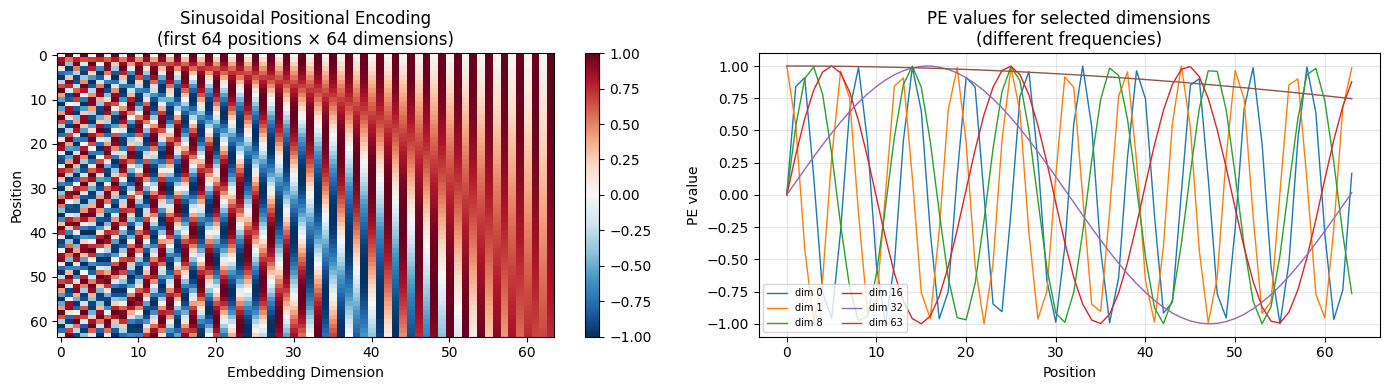

✅ PositionalEncoding verified.
Notice: lower dimensions have higher frequency (fast oscillation)
        higher dimensions have lower frequency (slow oscillation)
This creates a unique fingerprint for each position.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 5.4 — SINUSOIDAL POSITIONAL ENCODING (FROM SCRATCH)
# ─────────────────────────────────────────────────────────────

class SinusoidalPositionalEncoding(nn.Module):
    """
    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
    
    This encoding:
    - Is deterministic (not learned) → fewer parameters
    - Generalizes to sequences longer than seen during training
    - Allows the model to compute relative positions from absolute ones
      (sin(a+b) = sin(a)cos(b) + cos(a)sin(b))
    
    Adds to input: (B, T, d) + (1, T, d) → (B, T, d)
    """
    def __init__(self, embed_dim: int, max_seq_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Precompute PE table: (max_seq_len, embed_dim)
        pe = torch.zeros(max_seq_len, embed_dim)  # (T_max, d)
        
        # Position indices: (T_max, 1)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        
        # Frequency terms: (d/2,)
        # div_term[i] = 1 / 10000^(2i/d)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float) *
            (-math.log(10000.0) / embed_dim)
        )
        
        # Fill even indices with sin, odd with cos
        pe[:, 0::2] = torch.sin(position * div_term)  # (T, d/2)
        pe[:, 1::2] = torch.cos(position * div_term)  # (T, d/2)
        
        # Add batch dimension and register as buffer (not a parameter)
        pe = pe.unsqueeze(0)  # (1, T_max, d)
        self.register_buffer('pe', pe)  # saved in state_dict, not updated by optimizer
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, T, d)
        returns: (B, T, d) with positional encoding added
        """
        T = x.size(1)
        # self.pe: (1, T_max, d) → slice to (1, T, d)
        x = x + self.pe[:, :T, :]  # broadcasting over batch
        return self.dropout(x)


# Verify
pos_enc = SinusoidalPositionalEncoding(embed_dim=EMBED_DIM, max_seq_len=512)
x_test = torch.randn(2, 64, EMBED_DIM)
x_out  = pos_enc(x_test)
print(f"PositionalEncoding: {x_test.shape} → {x_out.shape}")

# Visualize the PE table
pe_table = pos_enc.pe[0].detach().numpy()  # (T_max, d)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(pe_table[:64, :64], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Sinusoidal Positional Encoding\n(first 64 positions × 64 dimensions)')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Position')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Show individual dimensions
for dim in [0, 1, 8, 16, 32, 63]:
    axes[1].plot(pe_table[:64, dim], label=f'dim {dim}', linewidth=1)
axes[1].set_title('PE values for selected dimensions\n(different frequencies)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('PE value')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../") /  'figures' / 'tran_scratch'/'fig_positional_encoding.png', dpi=120)
plt.show()
print("✅ PositionalEncoding verified.")
print("Notice: lower dimensions have higher frequency (fast oscillation)")
print("        higher dimensions have lower frequency (slow oscillation)")
print("This creates a unique fingerprint for each position.")

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5.5 — ENCODER BLOCK + TRANSFORMER ENCODER
# ─────────────────────────────────────────────────────────────

class FeedForwardNetwork(nn.Module):
    """
    FFN(x) = GELU(xW₁ + b₁)W₂ + b₂
    Expands: d → d_ff → d
    Applied independently to each position.
    """
    def __init__(self, embed_dim: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)   # (d → d_ff)
        self.linear2 = nn.Linear(ffn_dim, embed_dim)   # (d_ff → d)
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x):
        # (B, T, d) → (B, T, d_ff) → (B, T, d)
        return self.linear2(self.dropout(F.gelu(self.linear1(x))))


class EncoderBlock(nn.Module):
    """
    One Transformer Encoder Block:
        x1 = LayerNorm(x  + MultiHeadAttn(x, x, x))   ← pre-norm variant (more stable)
        x2 = LayerNorm(x1 + FFN(x1))
    
    Note: We use Pre-LayerNorm (norm before sublayer) for training stability.
    Original Transformer uses Post-LayerNorm, but Pre-LN is standard in modern work.
    """
    def __init__(self, embed_dim: int, num_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.ffn       = FeedForwardNetwork(embed_dim, ffn_dim, dropout)
        self.norm1     = nn.LayerNorm(embed_dim)
        self.norm2     = nn.LayerNorm(embed_dim)
        self.dropout   = nn.Dropout(p=dropout)
    
    def forward(self, x, mask=None):
        """
        x   : (B, T, d)
        mask: (B, 1, 1, T) or None
        returns: (B, T, d)
        """
        # Self-attention sublayer with residual
        x_norm = self.norm1(x)
        attn_out, _ = self.self_attn(x_norm, x_norm, x_norm, mask=mask)
        x = x + self.dropout(attn_out)  # residual
        
        # FFN sublayer with residual
        x = x + self.dropout(self.ffn(self.norm2(x)))  # residual
        
        return x


class TransformerEncoder(nn.Module):
    """
    Stack of N EncoderBlocks.
    Input/Output: (B, T, embed_dim)
    """
    def __init__(self, embed_dim: int, num_heads: int, num_layers: int,
                 ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask=mask)
        return self.final_norm(x)


# Verify
enc = TransformerEncoder(EMBED_DIM, NUM_HEADS, NUM_LAYERS, FFN_DIM, DROPOUT)
x_test = torch.randn(2, 64, EMBED_DIM)
out = enc(x_test)

total_params = sum(p.numel() for p in enc.parameters())
print(f"TransformerEncoder:")
print(f"  Input : {x_test.shape}")
print(f"  Output: {out.shape}")
print(f"  Total parameters: {total_params:,}")
assert out.shape == x_test.shape
print("✅ TransformerEncoder verified.")

TransformerEncoder:
  Input : torch.Size([2, 64, 128])
  Output: torch.Size([2, 64, 128])
  Total parameters: 264,192
✅ TransformerEncoder verified.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 5.6 — THREE MODALITY-SPECIFIC TRANSFORMERS
# ─────────────────────────────────────────────────────────────

class AudioTransformer(nn.Module):
    """
    Audio Transformer: mel spectrogram patches → audio embedding.
    
    Pipeline:
        patches  : (B, N_patches, patch_dim)  e.g. (B, 64, 256)
        → Linear projection  : (B, 64, 128)
        → + Positional Encoding
        → TransformerEncoder : (B, 64, 128)
        → Mean pooling       : (B, 128)  ← audio embedding
    """
    def __init__(self, patch_dim: int, embed_dim: int, num_heads: int,
                 num_layers: int, ffn_dim: int, n_patches: int, dropout: float = 0.1):
        super().__init__()
        # Project each patch from patch_dim to embed_dim
        self.patch_proj = nn.Linear(patch_dim, embed_dim)  # (256 → 128)
        self.pos_enc    = SinusoidalPositionalEncoding(embed_dim, max_seq_len=n_patches + 1, dropout=dropout)
        self.encoder    = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm       = nn.LayerNorm(embed_dim)
    
    def forward(self, patches: torch.Tensor) -> torch.Tensor:
        """
        patches: (B, N_patches, patch_dim)
        returns: (B, embed_dim)  — mean-pooled audio embedding
        """
        x = self.patch_proj(patches)  # (B, N_patches, embed_dim)
        x = self.pos_enc(x)           # add position info
        x = self.encoder(x)           # (B, N_patches, embed_dim)
        x = x.mean(dim=1)             # mean pooling over patches → (B, embed_dim)
        return self.norm(x)


class LyricsTransformer(nn.Module):
    """
    Lyrics Transformer: token IDs → lyrics embedding.
    
    Pipeline:
        token_ids  : (B, L)        e.g. (B, 256)
        → Embedding layer : (B, L, 128)
        → + Positional Encoding
        → TransformerEncoder (with attention mask)
        → Masked mean pooling : (B, 128)  ← lyrics embedding
    """
    def __init__(self, vocab_size: int, embed_dim: int, num_heads: int,
                 num_layers: int, ffn_dim: int, max_seq_len: int, dropout: float = 0.1):
        super().__init__()
        # Learnable embedding lookup table (V × d)
        self.token_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # PAD_ID=0
        self.pos_enc     = SinusoidalPositionalEncoding(embed_dim, max_seq_len=max_seq_len + 1, dropout=dropout)
        self.encoder     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm        = nn.LayerNorm(embed_dim)
    
    def forward(self, token_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """
        token_ids     : (B, L)  int64
        attention_mask: (B, L)  int64 (1 = real, 0 = pad)
        returns       : (B, embed_dim)  masked mean-pooled lyrics embedding
        """
        # Embedding lookup: (B, L) → (B, L, d)
        x = self.token_embed(token_ids)
        x = self.pos_enc(x)
        
        # Create 4D attention mask for MultiHeadAttention
        # (B, L) → (B, 1, 1, L)  — broadcast over heads and query positions
        mask_4d = attention_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, L)
        
        x = self.encoder(x, mask=mask_4d)  # (B, L, d)
        
        # Masked mean pooling: only average over real (non-padding) tokens
        mask_f = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
        x_masked = x * mask_f                           # zero out padding positions
        sum_embed = x_masked.sum(dim=1)                 # (B, d)
        token_count = mask_f.sum(dim=1).clamp(min=1)   # (B, 1), avoid /0
        x = sum_embed / token_count                     # (B, d)
        
        return self.norm(x)

'''
class VisionTransformer(nn.Module):
    """
    Vision Transformer: image patches → image embedding.
    
    Pipeline:
        patches : (B, 196, 768)
        → Linear projection  : (B, 196, 128)
        → Prepend [CLS] token: (B, 197, 128)
        → + Positional Encoding
        → TransformerEncoder : (B, 197, 128)
        → output[:, 0, :]    : (B, 128)  ← CLS token = image embedding
    """
    def __init__(self, patch_dim: int, embed_dim: int, num_heads: int,
                 num_layers: int, ffn_dim: int, n_patches: int, dropout: float = 0.1):
        super().__init__()
        self.patch_proj = nn.Linear(patch_dim, embed_dim)  # (768 → 128)
        # Learnable [CLS] token, shape (1, 1, embed_dim)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_enc    = SinusoidalPositionalEncoding(embed_dim, max_seq_len=n_patches + 2, dropout=dropout)
        self.encoder    = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm       = nn.LayerNorm(embed_dim)
    
    def forward(self, patches: torch.Tensor) -> torch.Tensor:
        """
        patches: (B, N_patches, patch_dim)
        returns: (B, embed_dim)  — CLS token embedding
        """
        B = patches.size(0)
        
        x = self.patch_proj(patches)  # (B, 196, 128)
        
        # Expand CLS token for batch and prepend
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, 128)
        x   = torch.cat([cls, x], dim=1)         # (B, 197, 128)
        
        x = self.pos_enc(x)    # add positions
        x = self.encoder(x)    # (B, 197, 128)
        
        # Take CLS token output as image embedding
        return self.norm(x[:, 0, :])  # (B, 128)
'''
class VisualProjector(nn.Module):
    """Projects ResNet-4096 into the shared 128-dim latent space."""
    def __init__(self, resnet_dim, embed_dim, dropout=0.1):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(resnet_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, embed_dim) # Align to 128d
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, resnet_vec):
        # resnet_vec is (Batch, 4096)
        return self.norm(self.projector(resnet_vec))

# ── Instantiate and verify all three ─────────────────────────
audio_transformer = AudioTransformer(
    patch_dim=AUDIO_PATCH_DIM, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, ffn_dim=FFN_DIM, n_patches=AUDIO_N_PATCHES, dropout=DROPOUT
).to(device)

lyrics_transformer = LyricsTransformer(
    vocab_size=LYRICS_VOCAB, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, ffn_dim=FFN_DIM, max_seq_len=LYRICS_MAX_LEN, dropout=DROPOUT
).to(device)

vision_transformer = VisualProjector(RESNET_DIM, EMBED_DIM, DROPOUT).to(device)


print("=" * 55)
print("ALL THREE TRANSFORMERS — PARAMETER COUNT SUMMARY")
print("=" * 55)

for name, model in [('AudioTransformer', audio_transformer),
                     ('LyricsTransformer', lyrics_transformer),
                     ('VisionTransformer', vision_transformer)]:
    n_params = sum(p.numel() for p in model.parameters())
    n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:<22} : {n_params:>8,} params  ({n_params*4/1024:.0f} KB)")

print()
print("Shape verification:")

# Audio
audio_patches = torch.randn(2, AUDIO_N_PATCHES, AUDIO_PATCH_DIM).to(device)
audio_emb = audio_transformer(audio_patches)
print(f"  Audio:  ({2},{AUDIO_N_PATCHES},{AUDIO_PATCH_DIM}) → {audio_emb.shape}")
assert audio_emb.shape == (2, EMBED_DIM)

# Lyrics
token_ids = torch.randint(0, LYRICS_VOCAB, (2, LYRICS_MAX_LEN)).to(device)
attn_mask = torch.ones(2, LYRICS_MAX_LEN, dtype=torch.long).to(device)
attn_mask[0, 100:] = 0  # simulate padding
lyrics_emb = lyrics_transformer(token_ids, attn_mask)
print(f"  Lyrics: ({2},{LYRICS_MAX_LEN}) ids + mask → {lyrics_emb.shape}")
assert lyrics_emb.shape == (2, EMBED_DIM)

# Vision
resnet_dummy = torch.randn(2, RESNET_DIM).to(device)
image_emb = vision_transformer(resnet_dummy)
print(f"  Visual: (2, {RESNET_DIM}) → {image_emb.shape}")
assert image_emb.shape == (2, EMBED_DIM)


print()
print("✅ All three transformers verified.")
print(f"   Each outputs: (B, {EMBED_DIM}) embedding per song.")
print(f"   These will be fed into the Multimodal Fusion module (Notebook 6).")

ALL THREE TRANSFORMERS — PARAMETER COUNT SUMMARY
  AudioTransformer       :  297,344 params  (1162 KB)
  LyricsTransformer      : 2,198,400 params  (8588 KB)
  VisionTransformer      : 2,163,584 params  (8452 KB)

Shape verification:
  Audio:  (2,64,256) → torch.Size([2, 128])
  Lyrics: (2,256) ids + mask → torch.Size([2, 128])
  Visual: (2, 4096) → torch.Size([2, 128])

✅ All three transformers verified.
   Each outputs: (B, 128) embedding per song.
   These will be fed into the Multimodal Fusion module (Notebook 6).


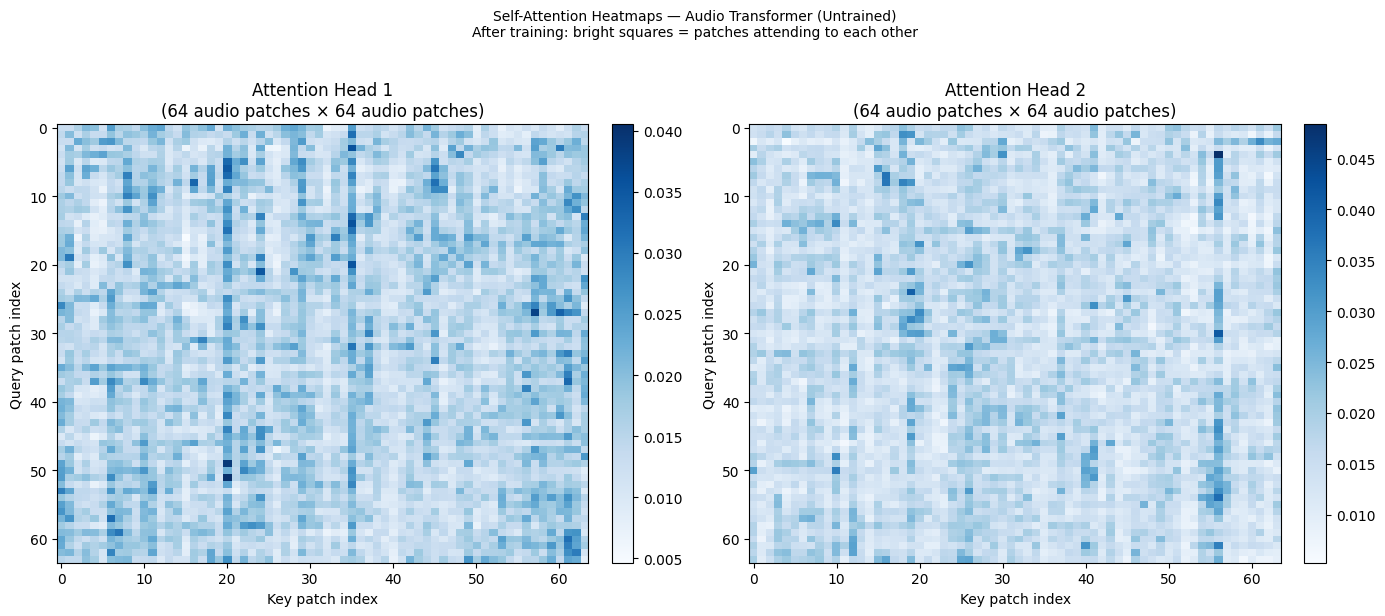

✅ Attention heatmap saved.

Interpretation:
  Before training: roughly uniform (random initialization)
  After training : sparse patterns emerge — the model learns which
  time-frequency patches are most important for identifying genre/mood.


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 5.7 — ATTENTION HEATMAP VISUALIZATION
# ─────────────────────────────────────────────────────────────

# Run a forward pass and extract attention weights
audio_transformer.eval()
with torch.no_grad():
    x_proj = audio_transformer.patch_proj(audio_patches)
    x_pos  = audio_transformer.pos_enc(x_proj)
    # Run through first encoder block and grab attention weights
    first_block = audio_transformer.encoder.layers[0]
    x_norm = first_block.norm1(x_pos)
    _, attn_weights = first_block.self_attn(x_norm, x_norm, x_norm)
    # attn_weights: (B=2, h=2, T=64, T=64)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for head_idx in range(NUM_HEADS):
    ax = axes[head_idx]
    attn_map = attn_weights[0, head_idx].cpu().numpy()  # (T, T)
    im = ax.imshow(attn_map, cmap='Blues', aspect='auto')
    ax.set_title(f'Attention Head {head_idx+1}\n'
                 f'(64 audio patches × 64 audio patches)')
    ax.set_xlabel('Key patch index')
    ax.set_ylabel('Query patch index')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Self-Attention Heatmaps — Audio Transformer (Untrained)\n'
             'After training: bright squares = patches attending to each other',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(Path("../") /  'figures' / 'tran_scratch'/'fig_attention_heatmap.png', dpi=120,bbox_inches='tight')

plt.show()
print("✅ Attention heatmap saved.")
print()
print("Interpretation:")
print("  Before training: roughly uniform (random initialization)")
print("  After training : sparse patterns emerge — the model learns which")
print("  time-frequency patches are most important for identifying genre/mood.")

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 5.8 — SAVE MODEL ARCHITECTURES AND CONFIGS
# ─────────────────────────────────────────────────────────────

import json

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save architecture config
config = {
    'embed_dim':         EMBED_DIM,
    'num_heads':         NUM_HEADS,
    'num_layers':        NUM_LAYERS,
    'ffn_dim':           FFN_DIM,
    'dropout':           DROPOUT,
    'audio_patch_dim':   AUDIO_PATCH_DIM,
    'audio_n_patches':   AUDIO_N_PATCHES,
    'lyrics_vocab_size': LYRICS_VOCAB,
    'lyrics_max_len':    LYRICS_MAX_LEN,
    'resnet_dim':        RESNET_DIM, # Replaced image patches with ResNet
}
with open(MODELS_DIR / 'transformer_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ Config saved to music_recommender/models/transformer_config.json")

# Save initialized model weights (for reproducible experiments)
torch.save({
    'audio_transformer':  audio_transformer.state_dict(),
    'lyrics_transformer': lyrics_transformer.state_dict(),
    'vision_transformer': vision_transformer.state_dict(),
}, MODELS_DIR / 'initialized_weights.pt')
print("✅ Initialized weights saved.")
print()
print("Summary — what each transformer produces:")
print(f"  AudioTransformer  : (B, {EMBED_DIM}) — acoustic embedding")
print(f"  LyricsTransformer : (B, {EMBED_DIM}) — semantic text embedding")
print(f"  VisionTransformer : (B, {EMBED_DIM}) — visual aesthetic embedding")
print()
print("These three embeddings feed into Notebook 6: Multimodal Fusion.")

✅ Config saved to music_recommender/models/transformer_config.json
✅ Initialized weights saved.

Summary — what each transformer produces:
  AudioTransformer  : (B, 128) — acoustic embedding
  LyricsTransformer : (B, 128) — semantic text embedding
  VisionTransformer : (B, 128) — visual aesthetic embedding

These three embeddings feed into Notebook 6: Multimodal Fusion.


---
## ✅ Notebook 5 Complete

**What was built from scratch:**
- `ScaledDotProductAttention` — QKV attention with masking and NaN handling
- `MultiHeadAttention` — parallel heads with split/merge and projections
- `SinusoidalPositionalEncoding` — mathematical position injection
- `FeedForwardNetwork` — position-wise expansion layer
- `EncoderBlock` — full transformer block with Pre-LayerNorm + residuals
- `TransformerEncoder` — N stacked blocks
- `AudioTransformer` — mel patches → (B, 128) acoustic embedding
- `LyricsTransformer` — token ids → (B, 128) text embedding with masked pooling
- `VisionTransformer` — image patches + CLS token → (B, 128) visual embedding

**Gradient flow summary:**
```
Loss → Ranking → Fusion → [Audio/Lyrics/Vision Transformer] → [Patch Projections]
Backprop flows through all layers via residual connections.
LayerNorm prevents gradient explosion.
```

**Next:** Notebook 6 — Multimodal Fusion (Cross-Attention + Gated Fusion → Unified Embedding)